# Distance to TLS and bronchi
In this notebook, we calculate set up distance axes: distance to TLS and distance to bronchi zone. Here we include the interior distance in the TLS as negative values. 

**Pinned Environment:** [`conda_envs/space2_20250604.yml`](../conda_envs/space2_20250604.yml)  

In [1]:
from pathlib import Path
import sys
import os
import time
import warnings
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata
import scanpy as sc
import squidpy as sq


import scipy
from scipy.spatial import distance_matrix
from scipy.spatial.distance import cdist
from scipy import stats
import scipy.ndimage as ndi
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks

from shapely.geometry import Point

from shapely.geometry import MultiPolygon
from alphashape import alphashape
from alphashape import optimizealpha
import geopandas as gpd

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer

import pickle
import joblib

import random
import matplotlib.colors as mcolors

import matplotlib as mpl
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['pdf.fonttype'] = 42

import warnings
warnings.simplefilter(action='ignore', category=Warning)

sys.version_info

sys.version_info(major=3, minor=12, micro=2, releaselevel='final', serial=0)

## Local file info

In [2]:
sys.path.append(str(Path.cwd().resolve().parents[0]))

from config.paths import BASE_OUTDIR, INPUTS_DIR, FUNCTIONS_DIR

inputs_dir = INPUTS_DIR
dist_out_dir = os.path.join(BASE_OUTDIR, "downstream_analysis/distance")


plot_out_dir = os.path.join(dist_out_dir, 'plots')

print(inputs_dir)
print(dist_out_dir)

/home/workspace/spatial_tls_manuscript/inputs
/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance


In [3]:
import importlib
if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.append(str(FUNCTIONS_DIR))

import plotting_utils as pu
import de_utils as du

In [4]:
importlib.reload(du)

<module 'de_utils' from '/home/workspace/spatial_tls_manuscript/utils/de_utils.py'>

## Load adata

In [5]:
adata = sc.read_h5ad(os.path.join(dist_out_dir,'adata_distance_zones_structure.h5ad'))

## Load palettes

In [5]:
with open(os.path.join(inputs_dir, '20250519_celltype_palette_mapped.pkl'), 'rb') as f:
    celltype_palette_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, '20250520_celltype_palette_coarse_mapped.pkl'), 'rb') as f:
    celltype_palette_coarse_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, '20250520_celltype_palette_coarser_mapped.pkl'), 'rb') as f:
    celltype_palette_coarser_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, '20250521_zone_consol_palette_mapped.pkl'), 'rb') as f:
    zone_consol_palette_mapped = pickle.load(f)

In [6]:
import matplotlib.colors as clr
import colorcet

zissou = [
    "#3A9AB2",
    "#6FB2C1",
    "#91BAB6",
    "#A5C2A3",
    "#BDC881",
    "#DCCB4E",
    "#E3B710",
    "#E79805",
    "#EC7A05",
    "#EF5703",
    "#F11B00",
]

colormap = clr.LinearSegmentedColormap.from_list("Zissou", zissou)
colormap_r = clr.LinearSegmentedColormap.from_list("Zissou", zissou[::-1])

## Calculate distance to TLS and distance to bronchi
We calculate the continuous distance to the TLS and the bronchi. 
- For the TLS, we use the polygons drawn around the TLS zone, which have been size filtered to exclude small TLS zone regions (see [`07_identify_structures.ipynb`](../initial_processing/07_identify_structures.ipynb)). Negative distances represent cells inside the TLS (interior distance from TLS edge), and positive distances represent cells outside the TLS.
- For the bronchi, we use the average distance to the nearnest n cells classified as zone bronchi. Cells in the bronchi zone are distance = 0.


In [ ]:
def cell_dist_to_zone(adata, cell_type_col, zone_col, zone_label, nearest_n, dist_col):
    
    # get coordinates of other cell type (the one we want to calculate the distance to)
    adata_other_type = adata[adata.obs[zone_col] == zone_label, :]
    zone_label_coords = adata_other_type.obs[['x_centroid', 'y_centroid']].values
    print('adata_other_type shape ', adata_other_type.shape)

    # first set all cells in adata with zone_col == zone_label to 0
    adata.obs.loc[adata.obs[zone_col] == zone_label, dist_col] = 0
    # now only calculate distances for other zones
    adata_other_zones = adata[adata.obs[zone_col] != zone_label, :]
    
    # Iterate over each unique cell type
    for cell_type in adata_other_zones.obs[cell_type_col].unique():

        # Filter AnnData object for the current cell type
        adata_filtered = adata_other_zones[adata_other_zones.obs[cell_type_col] == cell_type, :]
        adata_filtered_cell_type_indices = adata_filtered.obs.index
        # print('adata_cell_type shape ', adata_filtered.shape)
    
        # Get the coordinates of the cells of the current type
        cell_type_coords = adata_filtered.obs[['x_centroid', 'y_centroid']].values
        
        # Calculate the pairwise distances between the current cell type and other cell type
        pairwise_distances = cdist(cell_type_coords, zone_label_coords, metric='euclidean')
    
        # Sort distances and select nearest n
        nearest_distances = np.sort(pairwise_distances, axis=1)[:, :nearest_n]
        
        # Calculate the average distance to the nearest n cells
        avg_distance = np.mean(nearest_distances, axis=1)

        # Store distances in adata.obs 
        
        # Assigning values to the new column in the original DataFrame, using cell type filtered adata indices
        adata.obs.loc[adata_filtered_cell_type_indices, dist_col] = avg_distance

    return adata

In [ ]:
import numpy as np
from shapely.geometry import Point, Polygon, MultiPolygon
from tqdm import  tqdm

def calculate_distances_to_regions(adata, dist_out_dir):
    """
    Calculate distances from each cell to the closest TLS regions.
    Also determine if cells are inside these regions.
    
    Parameters
    ----------
    adata : AnnData
        The AnnData object containing spatial coordinates of cells
    dist_out_dir : str
        Directory where polygon files are stored
    
    Returns
    -------
    adata : AnnData
        Updated AnnData object with distance and boolean columns
    """
    # Create new columns in adata.obs for storing distances and boolean flags
    adata.obs['distance_to_tls'] = np.nan
    adata.obs['inside_tls'] = False
    
    # Process each sample separately
    for sample_label in adata.obs['sample_label'].cat.categories:
        print(f"Processing sample: {sample_label}")
        
        # Get cells for current sample
        sample_mask = adata.obs['sample_label'] == sample_label
        
        # Load TLS polygons for this sample
        tls_poly_path = os.path.join(dist_out_dir, f'tls_poly_{sample_label}.pkl')
        tls_poly = joblib.load(tls_poly_path)
        
        # Get spatial coordinates for cells in this sample
        coords = adata[sample_mask].obsm['spatial']
        
        # Calculate distances and check if cells are inside regions
        distances_to_tls = []
        inside_tls_flags = []
        
        for i, (x, y) in tqdm(enumerate(coords), total=len(coords), desc=f"Processing {sample_label}", ncols=100):
            # Create point for current cell
            point = Point(x, y)
            
            # Check TLS regions
            min_dist_tls = float('inf')
            is_inside_tls = False
            
            # Handle potential MultiPolygon case
            if isinstance(tls_poly, MultiPolygon):
                tls_polygons = list(tls_poly.geoms)
            else:
                tls_polygons = [tls_poly]
                
            for poly in tls_polygons:
                # Check if point is inside polygon
                if poly.contains(point):
                    min_dist_tls = 0
                    is_inside_tls = True
                    break
                # Calculate distance to polygon if not inside
                dist = point.distance(poly)
                if dist < min_dist_tls:
                    min_dist_tls = dist
            
            distances_to_tls.append(min_dist_tls)
            inside_tls_flags.append(is_inside_tls)
        
        # Update AnnData object with calculated values for this sample
        adata.obs.loc[sample_mask, 'distance_to_tls'] = distances_to_tls
        adata.obs.loc[sample_mask, 'inside_tls'] = inside_tls_flags
        
    return adata

In [ ]:
for zone_label in ['bronchi', 'vessels', 'TLS']:
    cell_type_col = 'label_fine'
    zone_col = 'zone_consol'
    dist_col = f'avg_distance_to_{zone_label}_zone'
    nearest_n = 10 
    
    start_time = time.time()
    
    adata.obs[dist_col] = np
    
    for sample_label in adata.obs['sample_label'].cat.categories:
        
        print(sample_label)
    
        adata_sample = adata[adata.obs['sample_label']==sample_label, :]
        
        # run distance calculation for each sample 
        adata_sample = cell_dist_to_zone(adata=adata_sample, 
                                                   cell_type_col=cell_type_col, 
                                                   zone_col=zone_col, 
                                                   zone_label=zone_label, 
                                                   nearest_n=nearest_n, 
                                                   dist_col=dist_col)
        
        # get distance df for each structure and add it back to the main adata object
        dist_df = adata_sample.obs[[dist_col]] 
        adata.obs.loc[dist_df.index, dist_col] = dist_df[dist_col]
    
    adata.obs[dist_col] = pd.to_numeric(adata.obs[dist_col])
    end_time = time.time()
    elapsed_time = (end_time - start_time) / 60
    print(elapsed_time, ' min')

calculate_distances_to_regions(adata, dist_out_dir)

# adata.write_h5ad(os.path.join(dist_out_dir,'adata_distance_zones_structure.h5ad'), compression='gzip')

## Calculate radial distance from TLS center to surroundings
1. Create surrounding ring around each tls with specified buffer distance from tls edge
2. For cells in the tls, compute the radial distance to the tls centroid within each tls
3. For cells in the tls surrounding, compute the radial distance to the tls edge
4. Add these values back to adata
5. Create scaled distances: Within tls, scale distance to centroid by max distance to centroid for each tls
6. Create scaled distances: Within tls surrounding, scale distance to tls edge by max distance to edge (eg buffer distance) for each tls surrounding

In [ ]:
from shapely.geometry import Point
import geopandas as gpd
from shapely.ops import nearest_points

def create_surrounding_ring(geom, buffer_distance=50):
    """Create a single ring geometry around a polygon (TLS)."""
    return geom.buffer(buffer_distance).difference(geom)

# params
buffer_distance = 50

# Init
adata.obs['tls_surr_index'] = 'none'
adata.obs['tls_radial_dist'] = np.nan
adata.obs['tls_radial_dist_surr'] = np.nan

# Process each sample
for sample_label in adata.obs['sample_label'].cat.categories:

    print(f"Processing sample: {sample_label}")
    
    # Subset AnnData
    adata_sample = adata[adata.obs['sample_label'] == sample_label, :]

    # Load TLS geometries
    tls_gdf = gpd.read_file(os.path.join(dist_out_dir, f'tls_gdf_{sample_label}.geojson'))

    # Add centroid columns
    tls_gdf["tls_centroid_x"] = tls_gdf.geometry.centroid.x
    tls_gdf["tls_centroid_y"] = tls_gdf.geometry.centroid.y

    # Create surrounding ring geometry
    tls_gdf['geometry_ring'] = tls_gdf.geometry.apply(create_surrounding_ring, buffer_distance=buffer_distance)

    # --- Prepare TLS core and ring GeoDataFrames ---
    core_gdf = tls_gdf[['id', 'tls_centroid_x', 'tls_centroid_y', 'geometry']]
    ring_gdf = tls_gdf[['id', 'geometry_ring']].rename(columns={'geometry_ring': 'geometry'})
    ring_gdf['tls_surr_index'] = ring_gdf['id']
    core_gdf = gpd.GeoDataFrame(core_gdf, crs=tls_gdf.crs)
    ring_gdf = gpd.GeoDataFrame(ring_gdf, crs=tls_gdf.crs)

    # --- Build cell coordinate GeoDataFrame --- CORE
    points_df = adata_sample.obs[['x_centroid', 'y_centroid']].copy()
    points_gdf = gpd.GeoDataFrame(
        points_df,
        geometry=gpd.points_from_xy(points_df.x_centroid, points_df.y_centroid),
        crs=core_gdf.crs
    )

    # --- Spatial join: cells in TLS cores ---
    core_joined = gpd.sjoin(points_gdf, core_gdf, how='left', predicate='within')
    core_joined = core_joined[~core_joined['id'].isna()]
    core_joined['tls_radial_dist'] = np.hypot(
        core_joined['x_centroid'] - core_joined['tls_centroid_x'],
        core_joined['y_centroid'] - core_joined['tls_centroid_y']
    )
    adata.obs.loc[core_joined.index, 'tls_radial_dist'] = core_joined['tls_radial_dist']




    
    # --- Spatial join: cells in TLS surrounding rings ---
    ring_joined = gpd.sjoin(points_gdf, ring_gdf, how='left', predicate='within')
    ring_joined = ring_joined[~ring_joined['tls_surr_index'].isna()]
    adata.obs.loc[ring_joined.index, 'tls_surr_index'] = ring_joined['tls_surr_index'].astype(str)

    # Before spatial join, add cell index to points_gdf
    points_gdf["cell_index"] = points_df.index
    
    # Re-do spatial join a
    ring_joined = gpd.sjoin(points_gdf, ring_gdf, how='left', predicate='within')
    
    # Drop NaNs
    ring_joined = ring_joined[~ring_joined['tls_surr_index'].isna()]

    # compute tls surrounding distance
    # Merge with original TLS geometry for edge distance
    ring_joined = ring_joined.merge(
        tls_gdf[['id', 'geometry']],
        left_on='tls_surr_index', right_on='id', how='left',
        suffixes=('', '_tls')
    )
    
    # Compute distance to TLS edge (not center!)
    from shapely.ops import nearest_points
    tls_surr_edge_dists = []
    
    for _, row in ring_joined.iterrows():
        cell_pt = row['geometry']
        tls_geom = row['geometry_tls']
        
        if cell_pt is not None and tls_geom is not None:
            edge_pt = nearest_points(cell_pt, tls_geom.boundary)[1]
            dist = cell_pt.distance(edge_pt)
            tls_surr_edge_dists.append(dist)
        else:
            tls_surr_edge_dists.append(np.nan)
    
    # Assign distances to column
    ring_joined['tls_radial_dist_surr'] = tls_surr_edge_dists
    

    # Assign back using cell_index
    adata.obs.loc[ring_joined['cell_index'], 'tls_radial_dist_surr'] = ring_joined['tls_radial_dist_surr'].values


# Make category dtype
adata.obs['tls_surr_index'] = adata.obs['tls_surr_index'].astype('category')

# Set surrounding ring fields to NaN for cells inside TLS
in_tls_mask = adata.obs['tls_index'].notna()
adata.obs.loc[in_tls_mask, 'tls_surr_index'] = np.nan
adata.obs.loc[in_tls_mask, 'tls_radial_dist_surr'] = np.nan


In [ ]:
# Initialize scaled columns
adata.obs['tls_radial_dist_scaled'] = np.nan
adata.obs['tls_radial_dist_surr_scaled'] = np.nan

# Loop through each TLS
for tls_id in adata.obs['tls_index'].dropna().unique():
    # Get cells assigned to this TLS (both core and surround)
    in_core = adata.obs['tls_index'] == tls_id
    in_surr = adata.obs['tls_surr_index'] == tls_id
    in_tls = in_core | in_surr

    # Skip if no distances exist
    if in_core.sum() == 0:
        continue

    # Get max distance from within-TLS cells
    max_core_dist = adata.obs.loc[in_core, 'tls_radial_dist'].max()
    # Get max distance from surrounding (should be equal to buffer distance)
    max_surr_dist = adata.obs.loc[in_surr, 'tls_radial_dist_surr'].max()

    # Scale core
    adata.obs.loc[in_core, 'tls_radial_dist_scaled'] = adata.obs.loc[in_core, 'tls_radial_dist'] / max_core_dist

    # Scale surround
    adata.obs.loc[in_surr, 'tls_radial_dist_surr_scaled'] = adata.obs.loc[in_surr, 'tls_radial_dist_surr'] / max_surr_dist


In [ ]:
# Now make a column that combines the scaled distance with in tls and within surrounding
adata.obs['tls_radial_dist_scaled_combined'] = adata.obs['tls_radial_dist_scaled'].copy()
adata.obs.loc[~adata.obs['tls_surr_index'].isna(), 'tls_radial_dist_scaled_combined'] = 1 + adata.obs['tls_radial_dist_surr_scaled']


In [ ]:
print('tls')
print(np.min(adata.obs['tls_radial_dist']))
print(np.max(adata.obs['tls_radial_dist']))

print('surrounding')
print(np.min(adata.obs['tls_radial_dist_surr']))
print(np.max(adata.obs['tls_radial_dist_surr']))

In [ ]:
print('tsls scaled')
print(np.min(adata.obs['tls_radial_dist_scaled']))
print(np.max(adata.obs['tls_radial_dist_scaled']))

print('surrounding scaled')
print(np.min(adata.obs['tls_radial_dist_surr_scaled']))
print(np.max(adata.obs['tls_radial_dist_surr_scaled']))

## Gate spatial regions based by distance to TLS and distance to bronchi 
Here, we leverage the concept of IMmune Allocation Plots (IMAPs) introduced in Reina-Campos et al., Nature, 2025.

In [ ]:
# Use a version where instead of all cells in TLS = 0, use the radial distance in/out
# adata = sc.read_h5ad(os.path.join(dist_out_dir,'adata_distance_zones_structure_tls_dist_categories.h5ad'))

In [ ]:
# def update_tls_distances(adata, inplace=True):
#     """
#     Updates 'distance_to_tls' for cells inside a TLS (d == 0) by replacing it 
#     with (max_radial_distance - current_radial_distance) within each unique TLS.
    
#     """
#     # Handle inplace vs copy
#     if not inplace:
#         adata = adata.copy()
    
#     # Identify the cells within TLS (d == 0) specifically within this subset
#     inTLS_idx = adata.obs.index[adata.obs['distance_to_tls'] == 0]
    
#     # Calculate tls_radial_dist_neg grouped by 'tls_index'
#     max_dist_per_tls = adata.obs.groupby('tls_index')['tls_radial_dist'].transform('max')
#     tls_radial_dist_neg = - (max_dist_per_tls - adata.obs['tls_radial_dist'])
    
#     # Apply the updates safely using .loc
#     adata.obs.loc[inTLS_idx, 'distance_to_tls'] = tls_radial_dist_neg.loc[inTLS_idx]


#     if not inplace:
#         return adata

In [ ]:
# # make sure tls indices are unique
# adata.obs['sample_tls_index'] = (adata.obs['sample'].astype(str)+adata.obs['tls_index'].astype(str)).astype('category')
# len(adata.obs['tls_index'].unique())
# len(adata.obs['sample_tls_index'].unique())

# # update distance to tls to include negative distances inside tls
# update_tls_distances(adata)

In [11]:
import matplotlib.patches as mpatches


def _draw_gates(ax, gates, x_clip, y_clip, show_labels=True, xlim=None, ylim=None):
    """Overlay named rectangular gates on a 2D distance plot.

    Each gate is {'x_min','x_max','y_min','y_max'} (any subset of keys), in RAW
    distance units. Missing/None bounds default to the plot edges
    (0 .. x_clip / y_clip).

    Gate borders are drawn as four independent line segments. If `xlim` / `ylim`
    (the view limits) are given, each border is drawn only where it lies within
    the view: a border whose constant edge is outside the limits is omitted, and
    borders running past an edge are clipped to it. This lets a gate whose bound
    sits beyond the axis (e.g. y_min below the y-axis minimum) still draw its
    in-view borders without a stray line off the plot.
    """
    def _clip_seg(a, b, lo, hi):
        """Clip the 1D segment spanning (a, b) to [lo, hi]; None if fully outside."""
        s0, s1 = min(a, b), max(a, b)
        s0, s1 = max(s0, lo), min(s1, hi)
        return (s0, s1) if s0 <= s1 else None

    for name, b in gates.items():
        x0 = b.get('x_min') if b.get('x_min') is not None else 0
        x1 = b.get('x_max') if b.get('x_max') is not None else x_clip
        y0 = b.get('y_min') if b.get('y_min') is not None else 0
        y1 = b.get('y_max') if b.get('y_max') is not None else y_clip

        xlo, xhi = xlim if xlim is not None else (min(x0, x1), max(x0, x1))
        ylo, yhi = ylim if ylim is not None else (min(y0, y1), max(y0, y1))

        # Horizontal borders (bottom=y0, top=y1): draw only if the edge's y is
        # within the y-view, clipped to the x-view.
        for ty in (y0, y1):
            if ylo <= ty <= yhi:
                seg = _clip_seg(x0, x1, xlo, xhi)
                if seg is not None:
                    ax.plot([seg[0], seg[1]], [ty, ty],
                            color='red', linestyle='-', linewidth=2)
        # Vertical borders (left=x0, right=x1): draw only if the edge's x is
        # within the x-view, clipped to the y-view.
        for tx in (x0, x1):
            if xlo <= tx <= xhi:
                seg = _clip_seg(y0, y1, ylo, yhi)
                if seg is not None:
                    ax.plot([tx, tx], [seg[0], seg[1]],
                            color='red', linestyle='-', linewidth=2)

        if show_labels:
            seg_x = _clip_seg(x0, x1, xlo, xhi)
            seg_y = _clip_seg(y0, y1, ylo, yhi)
            if seg_x is not None and seg_y is not None:
                # center the label on the VISIBLE portion of the gate
                ax.text((seg_x[0] + seg_x[1]) / 2, (seg_y[0] + seg_y[1]) / 2,
                        name, ha='center', va='center', fontsize=8, color='black')


def plot_celltype_density_2d(
    adata: sc.AnnData,
    sample_label: list[str],
    celltype: str = None,
    x_axis: str = 'avg_distance_to_bronchi_zone',
    y_axis: str = 'distance_to_tls',
    celltype_col: str = 'label_fine',
    gates: dict = None,
    x_clip: float = 450,
    y_clip: float = 450,
    x_ticks: list = None,
    y_ticks: list = None,
    max_cells: int = None,
    random_state: int = 0,
    figsize: tuple = (3, 3),
    point_size: float = 2,
    show_gate_labels: bool = True,
):
    """
    2D distance plot of the *density* of a cell population.

    Like `distance_xy_kde`, but instead of weighting by gene expression this
    shows where cells concentrate in the (x_axis, y_axis) distance space. Each
    cell is a point colored by its local 2D Gaussian-KDE density, with KDE
    contours.

    By default uses ALL cells; pass `celltype` to restrict to a single subset
    from `adata.obs[celltype_col]`. Optionally overlays rectangular `gates`
    (see `_draw_gates`) so different region definitions can be eyeballed before
    applying `assign_spatial_region`. Gate borders that fall outside the axis
    limits are omitted / clipped to the view.

    Subsampling
    -----------
    gaussian_kde evaluates an O(n^2) pairwise density, so plotting 300k+ cells
    (e.g. when celltype=None) is very slow and memory-heavy. Set `max_cells` to
    randomly downsample to at most that many points before the KDE; the density
    pattern is stable as long as max_cells is reasonably large (~20k+). Use
    `random_state` to control / vary the subsample.

    Use `x_ticks` / `y_ticks` to label the axes at chosen distance values, e.g.
    `y_ticks=[0, 25, 50, 100, 450]`. If omitted, matplotlib's default ticks are
    used.

    Parameters
    ----------
    adata : AnnData
    sample_label : list[str]
        sample_label values to include.
    celltype : str, optional
        Value in adata.obs[celltype_col] whose density is plotted. None (default)
        uses all cell types.
    celltype_col : str
        obs column holding the cell-type labels (default 'label_fine').
    x_axis, y_axis : str
        Distance columns for the x and y axes.
    gates : dict, optional
        region name -> {'x_min','x_max','y_min','y_max'} bounds (raw units) to overlay.
    x_clip, y_clip : float
        Axis limits in RAW units; cells beyond these are dropped from the plot.
    x_ticks, y_ticks : list, optional
        Distance values at which to place labeled ticks.
    max_cells : int, optional
        Randomly subsample to at most this many cells before the KDE. None = use all.
    random_state : int
        Seed for the subsample (default 0).
    point_size : float
        Scatter point size.

    Returns
    -------
    plt : module
        The pyplot module (call .show() or .savefig()).
    """
    fig = plt.figure(figsize=figsize, dpi=200)

    # Subset by sample_label
    adata = adata[adata.obs['sample_label'].isin(sample_label)]

    # Clip to the plotting window in RAW units (matches distance_xy_kde behavior)
    if x_clip:
        adata = adata[adata.obs[x_axis] <= x_clip, :]
    if y_clip:
        adata = adata[adata.obs[y_axis] <= y_clip, :]

    # Optionally subset to a cell type (celltype=None -> use all cell types)
    if celltype is not None:
        print(f"Subset to '{celltype_col}' == '{celltype}'")
        sub_adata = adata[adata.obs[celltype_col] == celltype].copy()
    else:
        print('Using all cell types')
        sub_adata = adata.copy()
    print('cells in subset: ', sub_adata.n_obs)

    # Downsample before the KDE if there are too many cells. gaussian_kde
    # evaluates an O(n^2) pairwise density, so 300k+ cells is very slow and
    # memory-heavy; cap the number of points used for the plot.
    if max_cells is not None and sub_adata.n_obs > max_cells:
        print(f'Subsampling {sub_adata.n_obs} -> {max_cells} cells for the density')
        sub_adata = sc.pp.subsample(sub_adata, n_obs=max_cells, copy=True,
                                    random_state=random_state)

    x = sub_adata.obs[x_axis].values
    y = sub_adata.obs[y_axis].values

    ax = fig.add_subplot(1, 1, 1)

    # color each cell by its local 2D density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    ax.scatter(x, y, c=z, s=point_size, marker='.', cmap='viridis')

    # density contours
    sns.kdeplot(x=x, y=y, ax=ax, color='#444444', linewidths=1)

    # axis limits with a small relative pad
    xpad = 0.02 * x_clip
    ypad = 0.02 * y_clip
    xlim = (-xpad, x_clip + xpad)
    # ylim = (-ypad, y_clip + ypad)
    ylim = (-100, y_clip + ypad)

    # overlay gates; borders outside the view limits are omitted / clipped
    if gates:
        _draw_gates(ax, gates, x_clip, y_clip,
                    show_labels=show_gate_labels, xlim=xlim, ylim=ylim)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    # ticks: label chosen distances if provided, else matplotlib defaults
    if x_ticks is not None:
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([str(t) for t in x_ticks])
    if y_ticks is not None:
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([str(t) for t in y_ticks])

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(False)
    plt.title(celltype if celltype is not None else 'all cells', fontsize=12)
    fig.tight_layout()
    return plt


In [12]:
def assign_spatial_region(
    adata: sc.AnnData,
    gates: dict,
    x_axis: str = 'avg_distance_to_bronchi_zone',
    y_axis: str = 'distance_to_tls',
    region_col: str = 'spatial_region',
    default: str = 'unassigned',
):
    """
    Label every cell with the spatial region it falls into, based on `gates`.

    Uses the same gate definition as `plot_celltype_density_2d` so what you
    draw is what you assign. Applied to ALL cells in `adata` (no clipping),
    writing the result to `adata.obs[region_col]` as an ordered Categorical.

    A cell is in a gate if its (x_axis, y_axis) coordinates satisfy every
    bound present in that gate: x_min <= x < x_max and y_min <= y < y_max
    (missing bounds are treated as open). Gates are applied in dict order
    and the LAST matching gate wins, so list overlapping gates from most
    general to most specific. Cells matching no gate get `default`.

    Parameters
    ----------
    adata : AnnData
    gates : dict
        region name -> {'x_min','x_max','y_min','y_max'} (any subset; None = open).
    x_axis, y_axis : str
        Columns in adata.obs holding the distance coordinates.
    region_col : str
        Output column written to adata.obs.
    default : str
        Label for cells not captured by any gate.

    Returns
    -------
    adata : AnnData
        The same object, with adata.obs[region_col] added.
    """
    x = adata.obs[x_axis].values
    y = adata.obs[y_axis].values
    region = np.full(adata.n_obs, default, dtype=object)

    for name, b in gates.items():
        mask = np.ones(adata.n_obs, dtype=bool)
        if b.get('x_min') is not None:
            mask &= x >= b['x_min']
        if b.get('x_max') is not None:
            mask &= x < b['x_max']
        if b.get('y_min') is not None:
            mask &= y >= b['y_min']
        if b.get('y_max') is not None:
            mask &= y < b['y_max']
        region[mask] = name

    categories = list(gates.keys())
    if (region == default).any():
        categories = categories + [default]
    adata.obs[region_col] = pd.Categorical(region, categories=categories, ordered=True)
    return adata

Subset to 'label_medium' == 'CD4 naive'
cells in subset:  1676


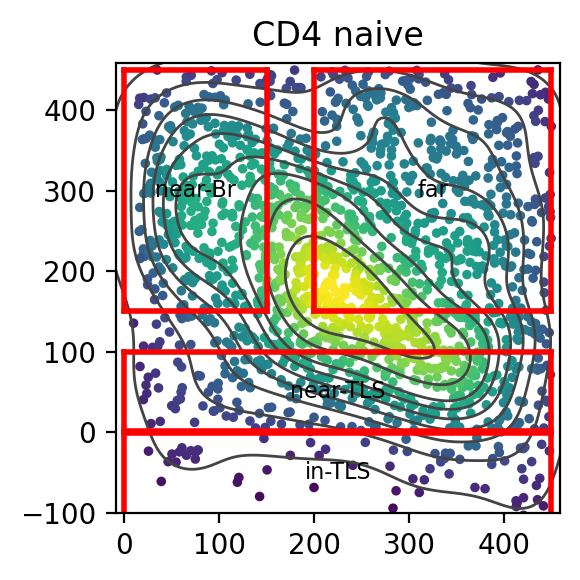

In [13]:
# x_axis = avg_distance_to_bronchi_zone, y_axis = distance_to_tls
sample_label = 'HDM_day3'
adata_plot = adata[adata.obs['sample_label'] == sample_label, :]
y_min = np.min(adata_plot.obs['distance_to_tls'])

gates = {
    'in-TLS': {'y_min':y_min, 'y_max': -1}, # in TLS
    'near-TLS':  {'y_min': 1, 'y_max': 100}, # close to TLS (any bronchi dist)
    'near-Br': {'x_max': 150, 'y_min': 150},      # close to bronchi, far from TLS
    'far':   {'x_min': 200, 'y_min': 150},      # far from both
}
p = plot_celltype_density_2d(
    adata_plot,
    sample_label=[sample_label],
    # celltype='Th0',
    # celltype_col='label_fine',
    celltype='CD4 naive',
    celltype_col='label_medium',  
    x_axis='avg_distance_to_bronchi_zone',
    y_axis='distance_to_tls',
    gates=gates,
    x_clip=450,
    y_clip=450,
    point_size=24,
    max_cells=5000
)
# plt.savefig(os.path.join(plot_out_dir, f"2D_density_CD4act_gates_{sample_label}.pdf"), dpi=300, bbox_inches='tight', transparent=True)
p.show()

Using all cell types
cells in subset:  222870
Subsampling 222870 -> 5000 cells for the density


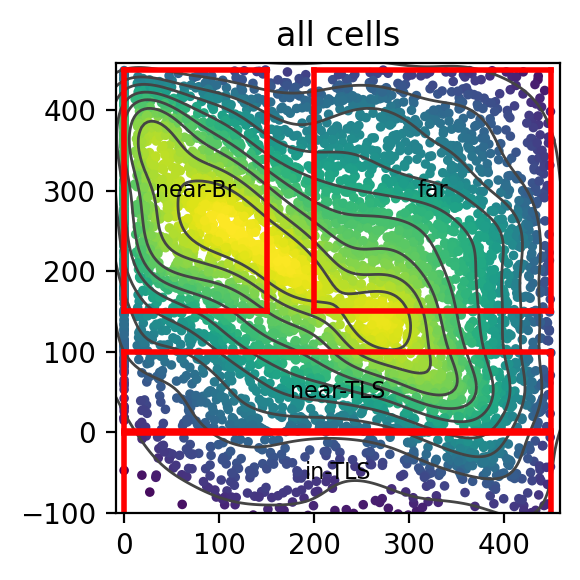

In [14]:
p = plot_celltype_density_2d(
    adata_plot,
    sample_label=[sample_label],
    celltype=None,
    x_axis='avg_distance_to_bronchi_zone',
    y_axis='distance_to_tls',
    gates=gates,
    x_clip=450,
    y_clip=450,
    point_size=24,
    max_cells = 5000,  
)

In [15]:
# Apply the gates to label every cell with the region it falls in.
# This writes adata.obs[region_col] for ALL cells (no clipping), so each
# cell gets a region using the same gate bounds drawn above.
adata = assign_spatial_region(
    adata,
    gates=gates,
    x_axis='avg_distance_to_bronchi_zone',
    y_axis='distance_to_tls',
    region_col='spatial_region',
)

adata.obs['spatial_region'].value_counts(dropna=False)

spatial_region
far           309532
near-Br       146590
unassigned     68503
near-TLS       47276
in-TLS         21336
Name: count, dtype: int64

## Plot cell type composition in these spatial regions

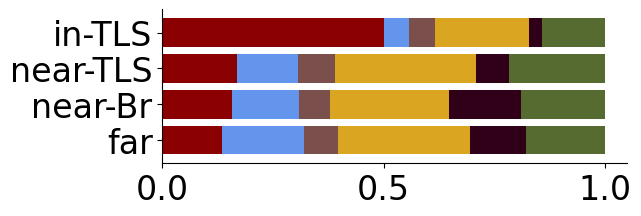

In [17]:
adata_plot = adata[adata.obs['spatial_region']!='unassigned', :]
ax1 = pu.zone_composition(adata_plot[adata_plot.obs['label_medium']=='CD4 act', :], 
                          label_col='label_fine', zone_col='spatial_region',
                            remove_unlabeled = True, 
                       palette_map = celltype_palette_mapped,
                       plot_counts = False, 
                       zone_ncell_filter = 50,
                       horizontal=True,
                       whitespace=0.8
                      )

ax1.figure.set_size_inches(6, 2)
ax1.tick_params(axis='x', labelsize=24)
ax1.tick_params(axis='y', labelsize=24)
ax1.set_title('')       
ax1.set_xlabel('')  
ax1.legend_.remove()

In [ ]:
import session_info
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()